# DNN Predictor : CliffWalking-v1 : N-Step

**Goal:** Find the best prediction horizon `n` for CliffWalking by training one
delta-prediction DNN per value of `n ∈ {2, 3, 5, 8}` and comparing validation MSE.

**Key differences vs CartPole:**
- Observation is a **discrete integer** (0–47, 4×12 grid) → one-hot encoded to a 48-dim vector
- **No normalization** needed (binary one-hot input is already in [0,1])
- 4 actions (Up / Down / Left / Right)
- Reward signal: −1/step, −100 cliff → delta magnitudes can be large on cliff transitions

**Output:** best `n`, saved model, config `.pt`

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device : cpu
PyTorch: 2.12.0+cpu


## Load & Unscramble the Dataset

The `.npz` file was shuffled across episodes before splitting (same scheme as CartPole).
We reconstruct the original chronological timeline by reversing the permutation so that
the n-step window builder never crosses an episode boundary.

In [4]:
DATA_PATH = r"..\data\collected\CliffWalking\transitions.npz"

N_STATES  = 48   # 4×12 grid
N_ACTIONS = 4    # Up / Down / Left / Right

# LOAD
npz = np.load(DATA_PATH, allow_pickle=True)
print("Keys in file:", list(npz.keys()))

# Load and concatenate splits (they are already separated in the file)
states_seq  = np.concatenate([
    npz["states_int_train"].astype(np.int32).ravel(),
    npz["states_int_val"].astype(np.int32).ravel(),
    npz["states_int_test"].astype(np.int32).ravel()
])

actions_seq = np.concatenate([
    npz["actions_train"].astype(np.int32).ravel(),
    npz["actions_val"].astype(np.int32).ravel(),
    npz["actions_test"].astype(np.int32).ravel()
])

dones_seq = np.concatenate([
    npz["dones_train"].ravel(),
    npz["dones_val"].ravel(),
    npz["dones_test"].ravel()
])

N = len(states_seq)
print(f"Total transitions: {N:,}")

print(f"states  range : [{states_seq.min()}, {states_seq.max()}]  (expect 0-47)")
print(f"actions range : [{actions_seq.min()}, {actions_seq.max()}]  (expect 0-3)")
print(f"dones   sum   : {dones_seq.sum():.0f}  (~number of episodes)")

Keys in file: ['states_int_train', 'states_train', 'actions_train', 'actions_onehot_train', 'rewards_train', 'rewards_norm_train', 'next_states_int_train', 'next_states_train', 'dones_train', 'episode_ids_train', 'states_int_val', 'states_val', 'actions_val', 'actions_onehot_val', 'rewards_val', 'rewards_norm_val', 'next_states_int_val', 'next_states_val', 'dones_val', 'episode_ids_val', 'states_int_test', 'states_test', 'actions_test', 'actions_onehot_test', 'rewards_test', 'rewards_norm_test', 'next_states_int_test', 'next_states_test', 'dones_test', 'episode_ids_test']
Total transitions: 97,388
states  range : [0, 36]  (expect 0-47)
actions range : [0, 3]  (expect 0-3)
dones   sum   : 26  (~number of episodes)


## One-Hot Encoding

CliffWalking observations are integers. We convert them to 48-dim one-hot vectors
so the network has no implicit ordinal relationship between cells.

Delta target:  `Δ = s_{t+n} − s_t`  (difference of one-hot vectors, values in {−1, 0, +1})
This is easier to predict than the absolute next state.

In [5]:
# One-hot encode the full timeline: shape (N, 48)
states_oh = np.eye(N_STATES, dtype=np.float32)[states_seq]   # (N, 48)

print(f"states_oh shape : {states_oh.shape}")
print(f"Sample row (state=12): {states_oh[np.where(states_seq==12)[0][0]][:15]}...")

# Quick sanity: delta between consecutive steps (not crossing done)
mask = (dones_seq[:-1] == 0)
delta_sample = states_oh[1:][mask] - states_oh[:-1][mask]
print(f"\nDelta stats (non-terminal steps):")
print(f"  min={delta_sample.min():.1f}  max={delta_sample.max():.1f}  "
      f"mean={delta_sample.mean():.4f}  std={delta_sample.std():.4f}")

states_oh shape : (97388, 48)
Sample row (state=12): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]...

Delta stats (non-terminal steps):
  min=-1.0  max=1.0  mean=0.0000  std=0.1695


## N-Step Window Builder

Slides a window of size `n` over the reconstructed timeline.
Any window whose action lookahead chain crosses an episode boundary is discarded
(dynamics are discontinuous at episode end / cliff fall).

Input : `concat(s_t_oh, a_t_oh, …, a_{t+n-1}_oh)`  →  shape `(48 + n×4,)`
Target: `s_{t+n}_oh − s_t_oh`  (delta, shape `(48,)`)

In [6]:
def build_nstep_dataset(states_oh, actions_seq, dones_seq, n):
    """
    Build (X, Y) pairs for n-step delta prediction.
    Skips windows that cross episode boundaries.
    """
    X_list, Y_list = [], []
    N = len(states_oh)

    # Pre-compute one-hot actions once
    act_oh = np.eye(N_ACTIONS, dtype=np.float32)[actions_seq]  # (N, 4)

    for t in range(N - n):
        # Drop window if any step inside ends an episode
        if np.any(dones_seq[t : t + n]):
            continue

        s_t  = states_oh[t]               # (48,)
        s_tn = states_oh[t + n]           # (48,)
        a_seq = act_oh[t : t + n].ravel() # (n*4,)

        X_list.append(np.concatenate([s_t, a_seq]))
        Y_list.append(s_tn - s_t)         # delta target

    X = torch.tensor(np.stack(X_list), dtype=torch.float32)
    Y = torch.tensor(np.stack(Y_list), dtype=torch.float32)
    print(f"  n={n}: {len(X):>7,} tuples | input {X.shape[1]:>4}D | target {Y.shape[1]}D")
    return X, Y


# ── Build datasets for all candidate n values ──────────────────────────────
N_STEP_VALUES = [1, 2, 3, 5, 8]
BATCH_SIZE    = 256

datasets = {}   # n → (X_train, Y_train, X_val, Y_val, X_test, Y_test)

print("Building n-step datasets...")
for n in N_STEP_VALUES:
    X_all, Y_all = build_nstep_dataset(states_oh, actions_seq, dones_seq, n)

    M  = len(X_all)
    perm = np.random.permutation(M)
    t_end = int(0.7 * M); v_end = int(0.8 * M)

    ti, vi, ei = perm[:t_end], perm[t_end:v_end], perm[v_end:]
    datasets[n] = (X_all[ti], Y_all[ti],
                   X_all[vi], Y_all[vi],
                   X_all[ei], Y_all[ei])

print("Done.")

Building n-step datasets...
  n=1:  97,362 tuples | input   52D | target 48D
  n=2:  97,336 tuples | input   56D | target 48D
  n=3:  97,310 tuples | input   60D | target 48D
  n=5:  97,258 tuples | input   68D | target 48D
  n=8:  97,180 tuples | input   80D | target 48D
Done.


## Model

A simple 3-layer MLP with Tanh activations (same family as the CartPole predictor).
Input dimension varies with `n`; output is always 48 (the delta over the one-hot state).

In [7]:
class StatePredictor(nn.Module):
    """
    MLP delta predictor for CliffWalking.
    input_dim = 48 + n*4  (state one-hot + n action one-hots)
    output_dim = 48       (Δ over the one-hot state vector)
    """
    def __init__(self, input_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.Tanh(),
            nn.Linear(hidden,    hidden), nn.Tanh(),
            nn.Linear(hidden,    48),
        )

    def forward(self, x):
        return self.net(x)


def make_loader(X, Y, shuffle=False):
    return DataLoader(TensorDataset(X, Y),
                      batch_size=BATCH_SIZE, shuffle=shuffle)


# Quick test
_tmp = StatePredictor(input_dim=48 + 1*4)
_x   = torch.zeros(4, 48 + 4)
print(f"Output shape for n=1: {_tmp(_x).shape}")  # expect (4, 48)

Output shape for n=1: torch.Size([4, 48])


## Train One Model per N

We train each model for up to 100 epochs with early stopping (patience=10).
Best checkpoint (by validation MSE) is saved per `n`.

In [8]:
def train_one(n, epochs=100, patience=10, hidden=128, lr=1e-3):
    X_tr, Y_tr, X_val, Y_val, _, _ = datasets[n]
    input_dim = X_tr.shape[1]

    model = StatePredictor(input_dim, hidden=hidden).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    tr_loader  = make_loader(X_tr,  Y_tr,  shuffle=True)
    val_loader = make_loader(X_val, Y_val, shuffle=False)

    history = {"train": [], "val": []}
    best_val, no_improve = float("inf"), 0
    best_state = None

    for ep in range(1, epochs + 1):
        # ── train ──
        model.train()
        tr_loss = 0.0
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            tr_loss += loss.item() * len(xb)
        tr_loss /= len(X_tr)

        # ── val ──
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_loss += loss_fn(model(xb), yb).item() * len(xb)
        val_loss /= len(X_val)

        history["train"].append(tr_loss)
        history["val"].append(val_loss)

        if val_loss < best_val - 1e-6:
            best_val   = val_loss
            no_improve = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1

        if ep % 10 == 0 or no_improve == patience:
            print(f"  n={n}  ep={ep:3d}  train={tr_loss:.5f}  val={val_loss:.5f}"
                  + ("  ← BEST" if no_improve == 0 else ""))

        if no_improve >= patience:
            print(f"  [early stop at epoch {ep}]")
            break

    model.load_state_dict(best_state)
    return model, history, best_val


# ── Run sweep ─────────────────────────────────────────────────────────────────
HIDDEN = 128
results   = {}   # n → (model, history, best_val_mse)

for n in N_STEP_VALUES:
    print(f"\n{'─'*50}")
    print(f" Training n = {n}")
    print(f"{'─'*50}")
    model, history, best_val = train_one(n, epochs=100, patience=10, hidden=HIDDEN)
    results[n] = (model, history, best_val)
    print(f" Best val MSE: {best_val:.6f}")


──────────────────────────────────────────────────
 Training n = 1
──────────────────────────────────────────────────
  n=1  ep= 10  train=0.00020  val=0.00020  ← BEST
  n=1  ep= 20  train=0.00001  val=0.00001  ← BEST
  n=1  ep= 30  train=0.00001  val=0.00000
  n=1  ep= 40  train=0.00001  val=0.00000
  n=1  ep= 41  train=0.00001  val=0.00000
  [early stop at epoch 41]
 Best val MSE: 0.000002

──────────────────────────────────────────────────
 Training n = 2
──────────────────────────────────────────────────
  n=2  ep= 10  train=0.00245  val=0.00218  ← BEST
  n=2  ep= 20  train=0.00074  val=0.00075  ← BEST
  n=2  ep= 30  train=0.00039  val=0.00041  ← BEST
  n=2  ep= 40  train=0.00024  val=0.00030
  n=2  ep= 50  train=0.00016  val=0.00017  ← BEST
  n=2  ep= 60  train=0.00012  val=0.00016
  n=2  ep= 70  train=0.00009  val=0.00010  ← BEST
  n=2  ep= 80  train=0.00007  val=0.00009
  n=2  ep= 90  train=0.00006  val=0.00007
  n=2  ep=100  train=0.00005  val=0.00006
 Best val MSE: 0.000050



## Training Curves & MSE Comparison

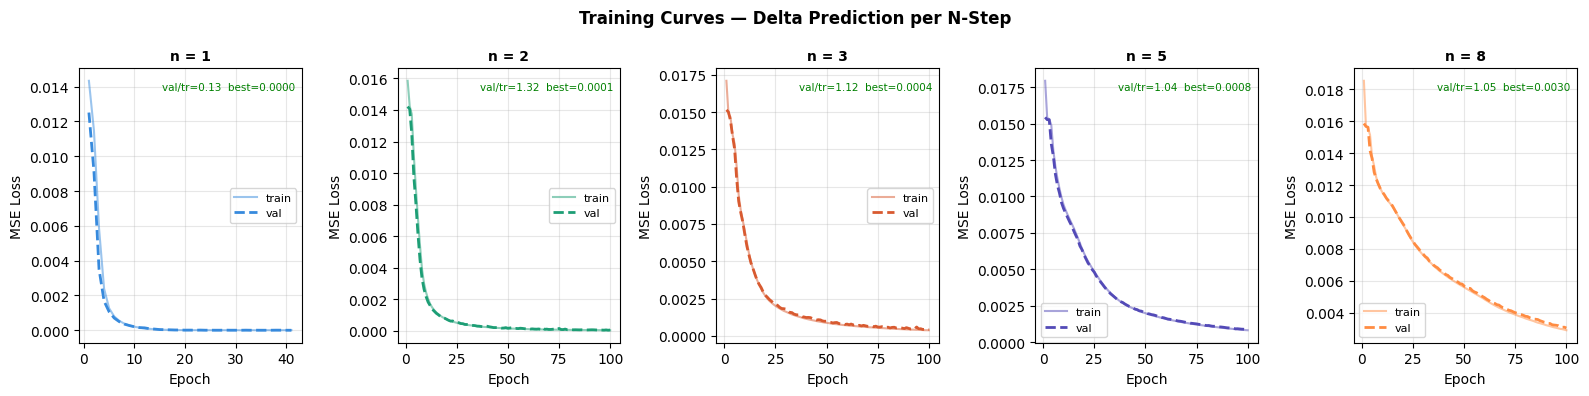

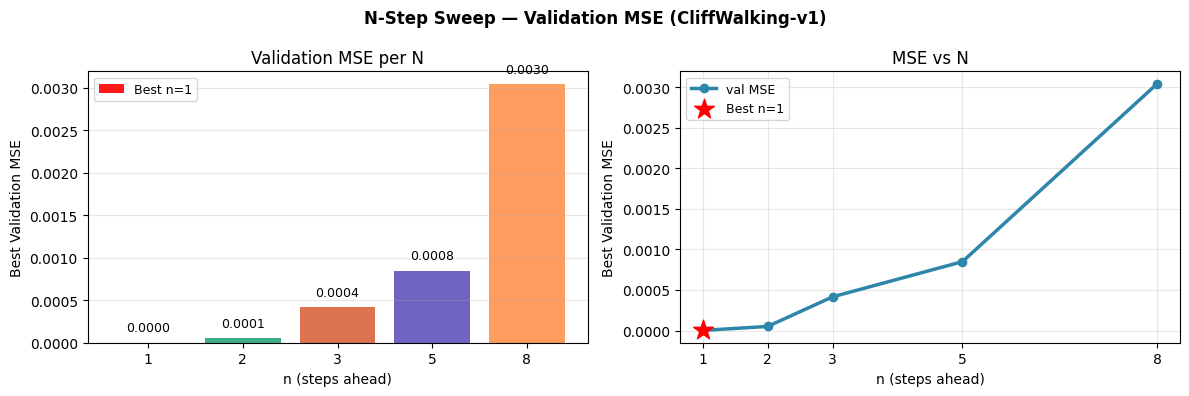


Best n = 1  (val MSE = 0.000002)


In [9]:
COLORS = ["#378ADD", "#1D9E75", "#D85A30", "#534AB7", "#FF8C42"]

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(N_STEP_VALUES), figsize=(16, 4))
fig.suptitle("Training Curves — Delta Prediction per N-Step", fontsize=12, fontweight="bold")

for ax, n, color in zip(axes, N_STEP_VALUES, COLORS):
    _, hist, bv = results[n]
    ep = range(1, len(hist["train"]) + 1)
    ax.plot(ep, hist["train"], color=color, lw=1.5, alpha=0.5, label="train")
    ax.plot(ep, hist["val"],   color=color, lw=2.0, linestyle="--", label="val")
    ratio = hist["val"][-1] / (hist["train"][-1] + 1e-9)
    ax.set_title(f"n = {n}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.text(0.97, 0.95, f"val/tr={ratio:.2f}  best={bv:.4f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=7.5,
            color="red" if ratio > 2.0 else "green")

plt.tight_layout()
plt.savefig("cliffwalking_training_curves.png", dpi=130)
plt.show()

# ── MSE comparison bar + line ─────────────────────────────────────────────────
best_mses = [results[n][2] for n in N_STEP_VALUES]
best_n    = N_STEP_VALUES[int(np.argmin(best_mses))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("N-Step Sweep — Validation MSE (CliffWalking-v1)", fontsize=12, fontweight="bold")

# bar
ax = axes[0]
bars = ax.bar([str(n) for n in N_STEP_VALUES], best_mses, color=COLORS, alpha=0.85)
for bar, mse in zip(bars, best_mses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1e-4,
            f"{mse:.4f}", ha="center", va="bottom", fontsize=9)
ax.bar([str(best_n)], [results[best_n][2]], color="red", alpha=0.9, label=f"Best n={best_n}")
ax.set_xlabel("n (steps ahead)"); ax.set_ylabel("Best Validation MSE")
ax.set_title("Validation MSE per N"); ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

# line
ax = axes[1]
ax.plot(N_STEP_VALUES, best_mses, marker="o", lw=2.5, color="#2E86AB", label="val MSE")
ax.scatter([best_n], [results[best_n][2]], color="red", s=220, zorder=5,
           marker="*", label=f"Best n={best_n}")
ax.set_xlabel("n (steps ahead)"); ax.set_ylabel("Best Validation MSE")
ax.set_title("MSE vs N"); ax.set_xticks(N_STEP_VALUES)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cliffwalking_nstep_comparison.png", dpi=130)
plt.show()

print(f"\nBest n = {best_n}  (val MSE = {results[best_n][2]:.6f})")

## Test Set Evaluation on Best Model

We measure MSE on the held-out test split and look at the predicted vs true
delta for a random subset of transitions.

Test MSE (best n=1): 0.000002


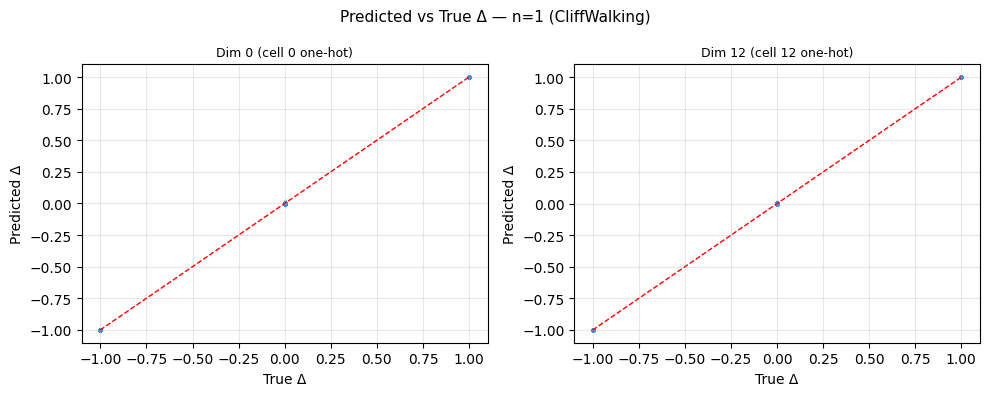

In [13]:
best_model, _, _ = results[best_n]
X_tr, Y_tr, X_val, Y_val, X_te, Y_te = datasets[best_n]

best_model.eval()
with torch.no_grad():
    pred_delta = best_model(X_te.to(DEVICE)).cpu()

# Reconstruct predicted next state (one-hot domain)
s_t_oh  = X_te[:, :N_STATES]             # first 48 dims are s_t one-hot
pred_stn = s_t_oh + pred_delta            # ŝ_{t+n} = s_t + Δ̂
true_stn = s_t_oh + Y_te                  # true s_{t+n} = s_t + Δ

test_mse = float(((pred_stn - true_stn) ** 2).mean())
print(f"Test MSE (best n={best_n}): {test_mse:.6f}")

# ── Residual scatter (sample 2000 points × 2 dims for readability) ───────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle(f"Predicted vs True Δ — n={best_n} (CliffWalking)", fontsize=11)

for ax, dim, label in zip(axes, [0, 12], ["Dim 0 (cell 0 one-hot)", "Dim 12 (cell 12 one-hot)"]):
    idx = np.random.choice(len(Y_te), min(2000, len(Y_te)), replace=False)
    true_d = Y_te[idx, dim].numpy()
    pred_d = pred_delta[idx, dim].numpy()
    ax.scatter(true_d, pred_d, s=4, alpha=0.3, color="#378ADD")
    lo, hi = min(true_d.min(), pred_d.min()), max(true_d.max(), pred_d.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)
    ax.set_xlabel("True Δ"); ax.set_ylabel("Predicted Δ")
    ax.set_title(label, fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cliffwalking_residuals.png", dpi=130)
plt.show()